# Analyzing Research Publication Trends with Polars

In this notebook we'll load a synthetic dataset of ~50,000 journal articles to explore
research output, citation patterns, and collaboration across different academic fields —
this time using **Polars** instead of Pandas.

**Topics covered:**
1. Data Loading
2. Inspection & summary statistics
3. Filtering & selection
4. Handling missing data
5. Data cleaning & standardization
6. GroupBy & aggregation
7. Joining datasets
8. Pivot tables
9. Time-series resampling
10. Visualization

## 1. Setup & Data Loading

In [13]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [14]:
# Polars infers types automatically; pub_date stays a string for now.
# Unlike pandas, pl.read_csv does NOT treat the literal text "nan" / "NaN" as null
# by default — we pass null_values so missing funding entries become proper nulls.
articles = pl.read_csv(
    "pandas_dataset.csv",
    null_values=["", "nan", "NaN", "NA"],
)

In [15]:
articles.head(10)

,article_id,title,field,pub_date,citations,author_count,open_access,funding_source
i64,i64,str,str,str,i64,i64,bool,str
0,1,"""Article_1""","""Physics""","""2024-05-20""",21,9,false,"""Government"""
1,2,"""Article_2""","""Chem""","""2022-11-25""",6,5,true,"""Industry"""
2,3,"""Article_3""","""Chemistry""","""2016-06-19""",11,3,true,"""University"""
3,4,"""Article_4""","""Psychology""","""2021-03-15""",36,4,false,"""University"""
4,5,"""Article_5""","""Biology""","""2018-10-09""",11,11,true,"""Foundation"""
5,6,"""Article_6""","""Biology""","""2018-01-28""",18,9,false,null
6,7,"""Article_7""","""Computer Science""","""2016-02-25""",101,6,false,"""Industry"""
7,8,"""Article_8""","""CS""","""2024-03-31""",26,4,true,"""Foundation"""
8,9,"""Article_9""","""Psychology""","""2024-02-04""",4,5,false,"""Foundation"""


## 2. Data Inspection & Summary Statistics

Let's examine dataset shape, types, and distributions.

In [16]:
articles.shape

(50000, 9)

In [17]:
# Polars equivalent of pandas .info() — show column names, types, and a preview.
articles.glimpse()

Rows: 50000
Columns: 9
$                 <i64> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
$ article_id      <i64> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
$ title           <str> 'Article_1', 'Article_2', 'Article_3', 'Article_4', 'Article_5', 'Article_6', 'Article_7', 'Article_8', 'Article_9', 'Article_10'
$ field           <str> 'Physics', 'Chem', 'Chemistry', 'Psychology', 'Biology', 'Biology', 'Computer Science', 'CS', 'Psychology', 'Chemistry'
$ pub_date        <str> '2024-05-20', '2022-11-25', '2016-06-19', '2021-03-15', '2018-10-09', '2018-01-28', '2016-02-25', '2024-03-31', '2024-02-04', '2021-10-12'
$ citations       <i64> 21, 6, 11, 36, 11, 18, 101, 26, 4, 6
$ author_count    <i64> 9, 5, 3, 4, 11, 9, 6, 4, 5, 5
$ open_access    <bool> False, True, True, False, True, False, False, True, False, False
$ funding_source  <str> 'Government', 'Industry', 'University', 'University', 'Foundation', null, 'Industry', 'Foundation', 'Foundation', 'University'



In [18]:
# Polars .describe() covers numeric AND string columns in one table
# (unlike pandas, which needs include="object" for strings).
articles.describe()

statistic,,article_id,title,field,pub_date,citations,author_count,open_access,funding_source
str,f64,f64,str,str,str,f64,f64,f64,str
"""count""",50000.0,50000.0,"""50000""","""50000""","""50000""",50000.0,50000.0,50000.0,"""37497"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,"""12503"""
"""mean""",24999.5,25000.5,null,null,null,32.00624,5.00822,0.45022,null
"""std""",14433.901067,14433.901067,null,null,null,77.604387,2.001468,null,null
"""min""",0.0,1.0,"""Article_1""","""Bio""","""2015-01-01""",0.0,1.0,0.0,"""Foundation"""
"""25%""",12500.0,12501.0,null,null,null,4.0,4.0,null,null
"""50%""",25000.0,25001.0,null,null,null,12.0,5.0,null,null
"""75%""",37499.0,37500.0,null,null,null,31.0,6.0,null,null
"""max""",49999.0,50000.0,"""Article_9999""","""Psychology""","""2024-06-30""",4371.0,16.0,1.0,"""University"""


In [19]:
# Check for missing values
articles.null_count()

,article_id,title,field,pub_date,citations,author_count,open_access,funding_source
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,12503


## 3. Filtering & Selection

Polars uses explicit expressions via `pl.col(...)` inside `.filter()`.
This enables lazy evaluation and query optimization.

In [20]:
# Open-access CS papers published after 2018 with > 50 citations
# First, convert pub_date from string to Date for proper comparisons
articles = articles.with_columns(
    pl.col("pub_date").str.to_date()
)

cs_labels = ["Computer Science", "CS", "Comp Sci"]

high_impact_cs = articles.filter(
    pl.col("field").is_in(cs_labels) &
    (pl.col("pub_date") >= pl.date(2019, 1, 1)) &
    (pl.col("citations") > 50) &
    (pl.col("open_access") == True)
)

print(f"Found {len(high_impact_cs)} articles matching the criteria")
high_impact_cs.select(["article_id", "field", "pub_date", "citations", "author_count"]).head(10)

Found 416 articles matching the criteria


article_id,field,pub_date,citations,author_count
i64,str,date,i64,i64
41,"""Computer Science""",2022-04-02,85,4
89,"""Comp Sci""",2020-10-26,83,8
101,"""Computer Science""",2019-03-30,93,5
184,"""Comp Sci""",2024-01-27,260,6
295,"""Computer Science""",2022-04-02,182,7
301,"""Computer Science""",2021-01-08,235,4
335,"""Computer Science""",2021-07-06,69,4
336,"""Computer Science""",2020-11-14,66,5
384,"""Comp Sci""",2024-05-25,151,5


In [21]:
# Polars also supports SQL via .sql() — a readable alternative to .filter()
result = articles.sql("""
    SELECT * FROM self
    WHERE field IN ('Computer Science', 'CS', 'Comp Sci')
      AND pub_date >= '2019-01-01'
      AND citations > 50
      AND open_access = true
""")
print(f"Same result: {len(result)} articles")

Same result: 416 articles


## 4. Handling Missing Data

Data in real datasets may have gaps.

Here the `funding_source` column has null values,
representing articles whose funding information wasn't recorded.

In [22]:
# How many articles are missing funding info?
missing_funding = articles["funding_source"].null_count()
pct = 100 * missing_funding / len(articles)
print(f"Missing funding_source: {missing_funding} ({pct:.1f}%)")

Missing funding_source: 12503 (25.0%)


In [23]:
# Option A: Fill missing values with a label
articles = articles.with_columns(
    pl.col("funding_source").fill_null("Unknown").alias("funding_filled")
)
articles["funding_filled"].value_counts().sort("count", descending=True)

funding_filled,count
str,u32
"""Government""",14876
"""Unknown""",12503
"""University""",10215
"""Industry""",7384
"""Foundation""",5022


In [24]:
# Option B: Drop rows with missing funding (careful — you lose data)
articles_complete = articles.drop_nulls(subset=["funding_source"])
print(f"Rows before: {len(articles)}, after drop_nulls: {len(articles_complete)}")

Rows before: 50000, after drop_nulls: 37497


## 5. Data Cleaning & Standardization

Notice that the `field` column has inconsistent names: "Computer Science", "CS", and "Comp Sci"
all mean the same thing. Let's fix it.

In [25]:
# See the messy values
print("Before cleaning:")
print(articles["field"].value_counts().sort("count", descending=True))

Before cleaning:
shape: (12, 2)
┌──────────────────┬───────┐
│ field            ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ Physics          ┆ 7094  │
│ Psychology       ┆ 7091  │
│ Computer Science ┆ 7021  │
│ Biology          ┆ 7016  │
│ Economics        ┆ 6933  │
│ …                ┆ …     │
│ CS               ┆ 1469  │
│ Psych            ┆ 1033  │
│ Bio              ┆ 1005  │
│ Comp Sci         ┆ 1000  │
│ Econ             ┆ 968   │
└──────────────────┴───────┘


In [26]:
# Build a mapping from messy names to canonical names
field_map = {
    "CS":       "Computer Science",
    "Comp Sci": "Computer Science",
    "Bio":      "Biology",
    "Econ":     "Economics",
    "Psych":    "Psychology",
    "Chem":     "Chemistry",
}

articles = articles.with_columns(
    pl.col("field").replace(field_map).alias("field_clean")
)

print("\nAfter cleaning:")
print(articles["field_clean"].value_counts().sort("count", descending=True))


After cleaning:
shape: (6, 2)
┌──────────────────┬───────┐
│ field_clean      ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ Computer Science ┆ 9490  │
│ Chemistry        ┆ 9370  │
│ Psychology       ┆ 8124  │
│ Biology          ┆ 8021  │
│ Economics        ┆ 7901  │
│ Physics          ┆ 7094  │
└──────────────────┴───────┘


## 6. GroupBy & Aggregation

GroupBy is arguably the most important Polars operation for analysis. It splits your data
into groups, applies an expression, and combines the results. Polars `.group_by().agg()`
is more explicit than pandas: every aggregation is spelled out as an expression.

In [27]:
# Mean citations by field
articles.group_by("field_clean").agg(
    pl.col("citations").mean()
).sort("citations", descending=True)

field_clean,citations
str,f64
"""Chemistry""",32.627321
"""Computer Science""",32.336354
"""Physics""",32.316747
"""Biology""",31.993143
"""Psychology""",31.673314
"""Economics""",30.950006


In [28]:
# Multiple aggregations at once
summary = (
    articles.group_by("field_clean")
    .agg(
        pl.len().alias("num_articles"),
        pl.col("citations").mean().alias("mean_citations"),
        pl.col("citations").median().alias("median_citations"),
        pl.col("author_count").mean().alias("mean_authors"),
        pl.col("open_access").mean().alias("pct_open_access"),
    )
    .with_columns(
        pl.col("mean_citations").round(2),
        pl.col("mean_authors").round(2),
        (pl.col("pct_open_access") * 100).round(1).alias("pct_open_access"),
    )
    .sort("mean_citations", descending=True)
)
summary

field_clean,num_articles,mean_citations,median_citations,mean_authors,pct_open_access
str,u32,f64,f64,f64,f64
"""Chemistry""",9370,32.63,12.0,5.0,44.4
"""Computer Science""",9490,32.34,12.0,5.01,45.4
"""Physics""",7094,32.32,12.0,5.02,44.7
"""Biology""",8021,31.99,12.0,4.99,44.5
"""Psychology""",8124,31.67,12.0,5.02,45.2
"""Economics""",7901,30.95,11.0,5.01,45.9


In [29]:
# Yearly publication counts by field — long form first, then pivot wide
yearly_long = (
    articles
    .with_columns(pl.col("pub_date").dt.year().alias("year"))
    .group_by(["year", "field_clean"])
    .agg(pl.len().alias("count"))
)

yearly = yearly_long.pivot(
    on="field_clean",
    index="year",
    values="count",
).sort("year").fill_null(0)

yearly

year,Economics,Biology,Chemistry,Computer Science,Psychology,Physics
i32,u32,u32,u32,u32,u32,u32
2015,867,842,958,1018,905,759
2016,902,811,1019,981,880,754
2017,827,850,971,983,835,777
2018,823,884,974,971,869,727
2019,828,800,992,1004,824,740
2020,793,884,986,987,868,700
2021,827,838,1024,1038,788,740
2022,783,851,965,1002,897,806
2023,855,816,979,1013,851,719


## 7. Joining Datasets

Often your data lives in multiple tables. Polars uses `.join()` (pandas calls it `.merge()`).
Let's create a journal-level dataset and join it with our articles to see whether journal
prestige correlates with citation count.

In [30]:
# Create a synthetic journal impact factor table
journals = pl.DataFrame({
    "field_clean": ["Computer Science", "Biology", "Physics",
                    "Economics", "Psychology", "Chemistry"],
    "avg_impact_factor": [5.2, 7.8, 6.1, 3.4, 4.5, 4.9],
    "avg_review_months": [4.2, 6.1, 5.0, 8.3, 7.5, 5.8],
})
journals

field_clean,avg_impact_factor,avg_review_months
str,f64,f64
"""Computer Science""",5.2,4.2
"""Biology""",7.8,6.1
"""Physics""",6.1,5.0
"""Economics""",3.4,8.3
"""Psychology""",4.5,7.5
"""Chemistry""",4.9,5.8


In [31]:
# Join on the cleaned field column
merged = articles.join(journals, on="field_clean", how="left")
print(f"Shape after join: {merged.shape}")
merged.select(["article_id", "field_clean", "citations", "avg_impact_factor"]).head()

Shape after join: (50000, 13)


article_id,field_clean,citations,avg_impact_factor
i64,str,i64,f64
1,"""Physics""",21,6.1
2,"""Chemistry""",6,4.9
3,"""Chemistry""",11,4.9
4,"""Psychology""",36,4.5
5,"""Biology""",11,7.8


In [32]:
# Correlation between impact factor and citations
corr = merged.select(["citations", "avg_impact_factor", "author_count"]).corr()
print("Correlation matrix:")
corr.with_columns(pl.all().round(3))

Correlation matrix:


citations,avg_impact_factor,author_count
f64,f64,f64
1.0,0.003,-0.005
0.003,1.0,-0.003
-0.005,-0.003,1.0


## 8. Pivot Tables

Pivot tables are a powerful way to reshape data for comparison. Let's look at how open-access
status relates to citation counts across fields.

In [33]:
# Cast boolean to a readable label before pivoting
oa_labelled = articles.with_columns(
    pl.when(pl.col("open_access"))
      .then(pl.lit("Open Access"))
      .otherwise(pl.lit("Closed Access"))
      .alias("oa_label")
)

pivot = oa_labelled.pivot(
    on="oa_label",
    index="field_clean",
    values="citations",
    aggregate_function="mean",
).with_columns(
    pl.col("Open Access").round(1),
    pl.col("Closed Access").round(1),
).with_columns(
    ((pl.col("Open Access") / pl.col("Closed Access") - 1) * 100)
        .round(1).alias("OA Advantage (%)")
).sort("OA Advantage (%)", descending=True)

pivot

field_clean,Closed Access,Open Access,OA Advantage (%)
str,f64,f64,f64
"""Economics""",29.8,32.3,8.4
"""Computer Science""",32.7,31.9,-2.4
"""Psychology""",32.1,31.2,-2.8
"""Biology""",32.4,31.5,-2.8
"""Chemistry""",33.2,31.9,-3.9
"""Physics""",33.0,31.4,-4.8


## 9. Time-Series Resampling

Since we have publication dates, we can look at trends over time. Polars uses
`.group_by_dynamic()` for time-based grouping (the equivalent of pandas `.resample()`)
and `.rolling_mean()` for smoothing.

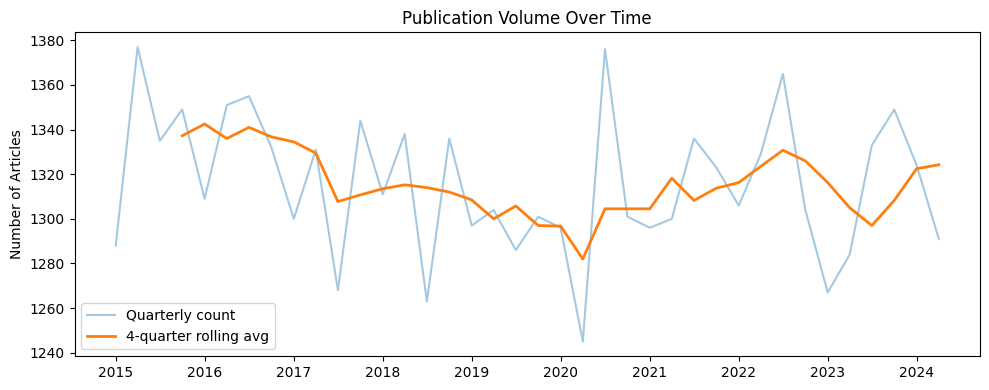

In [35]:
# group_by_dynamic requires a sorted temporal key
ts = articles.sort("pub_date")

# Quarterly publication counts
quarterly = (
    ts.group_by_dynamic("pub_date", every="1q")
      .agg(pl.len().alias("num_articles"))
      .with_columns(
          pl.col("num_articles").rolling_mean(window_size=4).alias("rolling_avg")
      )
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(quarterly["pub_date"], quarterly["num_articles"], alpha=0.4, label="Quarterly count")
ax.plot(quarterly["pub_date"], quarterly["rolling_avg"], linewidth=2, label="4-quarter rolling avg")
ax.set_title("Publication Volume Over Time")
ax.set_ylabel("Number of Articles")
ax.legend()
plt.tight_layout()
plt.show()

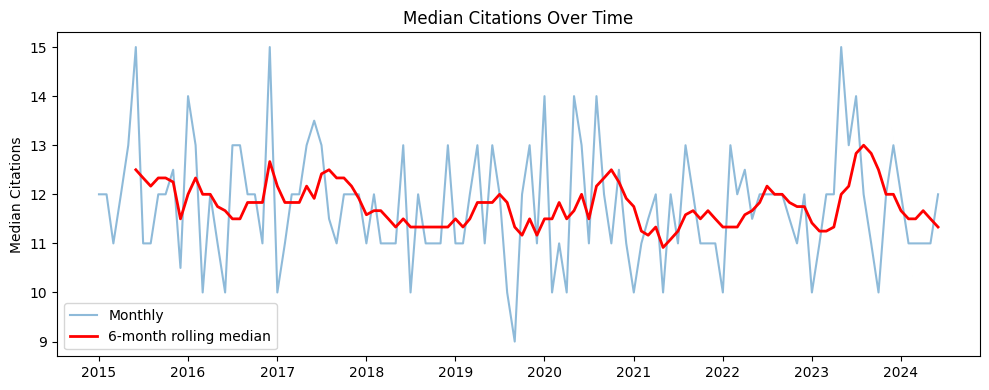

In [36]:
# Monthly median citations — are recent papers cited less (recency bias)?
monthly = (
    ts.group_by_dynamic("pub_date", every="1mo")
      .agg(pl.col("citations").median().alias("median_citations"))
      .with_columns(
          pl.col("median_citations").rolling_mean(window_size=6).alias("rolling_median")
      )
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["pub_date"], monthly["median_citations"], alpha=0.5, label="Monthly")
ax.plot(monthly["pub_date"], monthly["rolling_median"], linewidth=2, color="red", label="6-month rolling median")
ax.set_title("Median Citations Over Time")
ax.set_ylabel("Median Citations")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Visualization

Polars doesn't have a built-in `.plot()` accessor like Pandas does, so we pass its
Series to Matplotlib directly (Polars Series are NumPy-compatible via `.to_numpy()`
and iterate cleanly). For interactive plots you can also use `hvplot` or `plotly`.

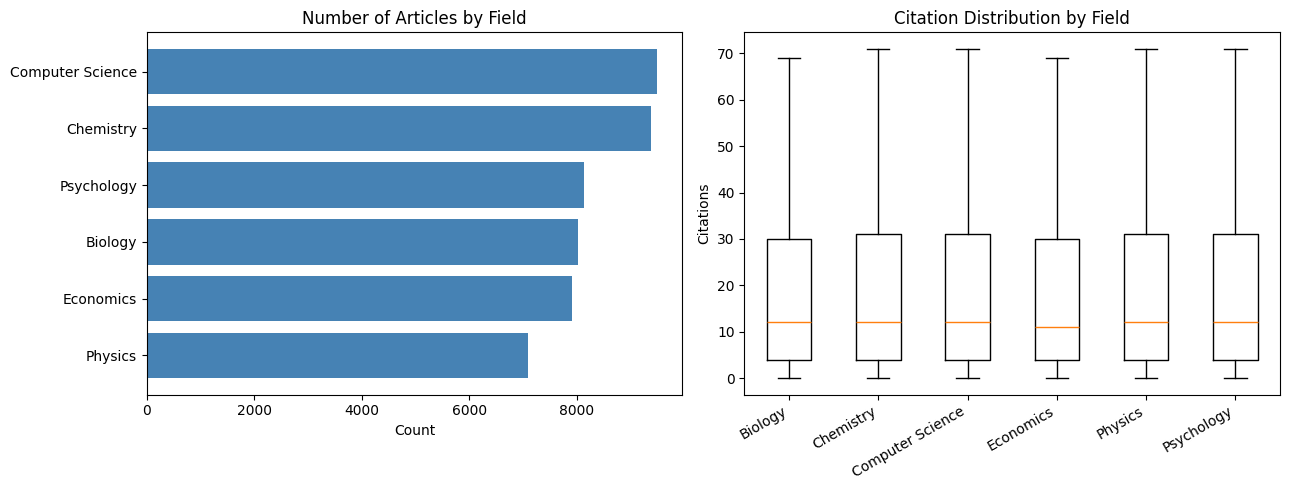

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: articles per field
field_counts = articles["field_clean"].value_counts().sort("count")
axes[0].barh(field_counts["field_clean"], field_counts["count"], color="steelblue")
axes[0].set_title("Number of Articles by Field")
axes[0].set_xlabel("Count")

# Box plot: citation distributions by field
fields = sorted(articles["field_clean"].unique().to_list())
box_data = [
    articles.filter(pl.col("field_clean") == f)["citations"].to_numpy()
    for f in fields
]
axes[1].boxplot(box_data, labels=fields, showfliers=False)
axes[1].set_title("Citation Distribution by Field")
axes[1].set_ylabel("Citations")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

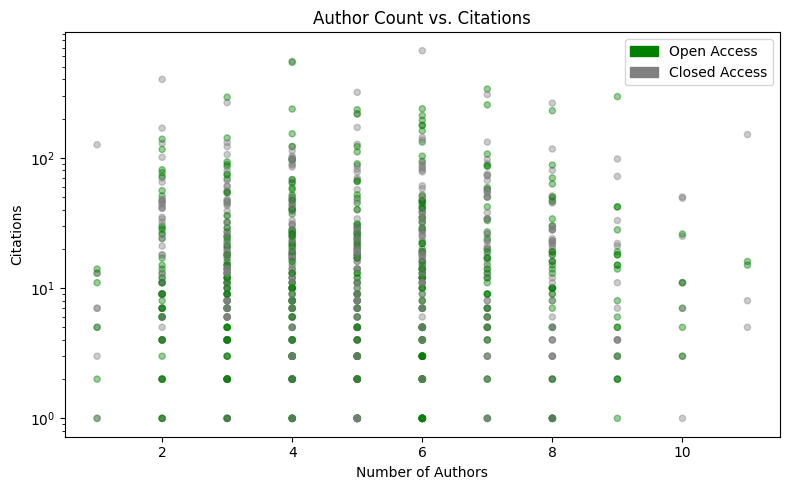

In [38]:
# Scatter: author count vs. citations (sampled for readability)
sample = articles.sample(n=1000, seed=42)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["green" if oa else "gray" for oa in sample["open_access"]]
ax.scatter(sample["author_count"], sample["citations"], c=colors, alpha=0.4, s=20)
ax.set_xlabel("Number of Authors")
ax.set_ylabel("Citations")
ax.set_title("Author Count vs. Citations")
ax.set_yscale("log")

# Manual legend
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="green", label="Open Access"),
    mpatches.Patch(color="gray",  label="Closed Access"),
])
plt.tight_layout()
plt.show()

## Summary & Next Steps

In this notebook we covered the same analytical workflow as the Pandas notebook, but
using Polars. Here's a quick translation reference:

| Pandas | Polars |
|---|---|
| `pd.read_csv()` | `pl.read_csv()` |
| `df.info()` | `df.glimpse()` |
| `df.isnull().sum()` | `df.null_count()` |
| `df[cond]`, `df.query()` | `df.filter(pl.col(...))`, `df.sql()` |
| `df.fillna(x)` | `df.with_columns(pl.col(c).fill_null(x))` |
| `df.dropna()` | `df.drop_nulls()` |
| `s.replace(mapping)` | `pl.col(c).replace(mapping)` |
| `df.groupby().agg()` | `df.group_by().agg()` |
| `df.merge()` | `df.join()` |
| `df.pivot_table()` | `df.pivot()` |
| `df.resample()` | `df.group_by_dynamic()` |
| `s.rolling(n).mean()` | `pl.col(c).rolling_mean(window_size=n)` |

**Why Polars?**
- Multi-threaded execution by default → much faster on large data.
- Lazy API (`pl.scan_csv(...).collect()`) enables query optimization.
- Explicit expressions make code easier to reason about and compose.
- Memory-efficient: typically uses 2–5× less RAM than Pandas.

**Next steps:**
- Rewrite the above using the lazy API (`pl.scan_csv` + `.collect()`) and compare performance.
- For datasets that don't fit in memory, try **[Polars streaming](https://docs.pola.rs/user-guide/concepts/streaming/)** or **Dask**.